In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!rm -rf /content/ppm_data
!unzip -o -q "/content/drive/MyDrive/Reference-PPM.zip" -d "/content/ppm_data"

import os
print("Files found:", len(os.listdir("/content/ppm_data/Reference-PPM")))

Files found: 2000


In [ ]:
import numpy as np
import scipy.io
import copy, json, os, shutil
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

TensorFlow version: 2.20.0
GPU available: False


In [ ]:
FOLDER = "/content/ppm_data/Reference-PPM"
TRACES_NO = 15000          # scaled up from your original 500/5000 runs
TRACES_PER_FILE = 100
N_FEATS = 50000
file_no = int(TRACES_NO / TRACES_PER_FILE)

vals = np.zeros((file_no * TRACES_PER_FILE, 12))
trace_kyber = np.zeros((file_no * TRACES_PER_FILE, N_FEATS), dtype=np.float32)

print(f"Loading {TRACES_NO} traces (this may take a while)...")
for ii in range(file_no):
    idx = np.arange(ii * TRACES_PER_FILE, (ii + 1) * TRACES_PER_FILE)

    path = f"{FOLDER}/tracesA{(ii + 1) * TRACES_PER_FILE - 1}.mat"
    mat = scipy.io.loadmat(path, squeeze_me=True)
    trace_kyber[idx, :] = np.array(mat["tracesA"], dtype=np.float32)

    path = f"{FOLDER}/noncesA{(ii + 1) * TRACES_PER_FILE - 1}.mat"
    mat = scipy.io.loadmat(path, squeeze_me=True)
    vals[idx, :] = np.array(mat["noncesA"], dtype=int)

    if (ii + 1) % 10 == 0 or ii == file_no - 1:
        print(f"Loaded file batch {ii + 1}/{file_no}")

print("Computing Hamming Weight labels (output value, cols 4,5)...")
labels = np.zeros(TRACES_NO, dtype=np.int32)
for j in range(TRACES_NO):
    labels[j] = bin(int(vals[j, 4])).count("1") + bin(int(vals[j, 5])).count("1")

traces = trace_kyber
print("Traces shape:", traces.shape)
print("Labels shape:", labels.shape)

unique, counts = np.unique(labels, return_counts=True)
print("Label distribution:")
for u, c in zip(unique, counts):
    print(f"  HW={int(u)}: {c}")

# Save to Drive immediately so a runtime reset never costs you this step again
np.save("/content/kyber_traces.npy", traces)
np.save("/content/kyber_labels.npy", labels)
np.save("/content/kyber_vals.npy", vals)
for f in ["kyber_traces.npy", "kyber_labels.npy", "kyber_vals.npy"]:
    shutil.copy(f"/content/{f}", f"/content/drive/MyDrive/{f}")
print("Saved locally AND backed up to Drive.")

Loading 15000 traces (this may take a while)...
Loaded file batch 10/150
Loaded file batch 20/150
Loaded file batch 30/150
Loaded file batch 40/150
Loaded file batch 50/150
Loaded file batch 60/150
Loaded file batch 70/150
Loaded file batch 80/150
Loaded file batch 90/150
Loaded file batch 100/150
Loaded file batch 110/150
Loaded file batch 120/150
Loaded file batch 130/150
Loaded file batch 140/150
Loaded file batch 150/150
Computing Hamming Weight labels (output value, cols 4,5)...
Traces shape: (15000, 50000)
Labels shape: (15000,)
Label distribution:
  HW=0: 4
  HW=1: 61
  HW=2: 238
  HW=3: 739
  HW=4: 1423
  HW=5: 1854
  HW=6: 1707
  HW=7: 1064
  HW=8: 817
  HW=9: 1084
  HW=10: 1682
  HW=11: 1786
  HW=12: 1478
  HW=13: 753
  HW=14: 243
  HW=15: 61
  HW=16: 6
Saved locally AND backed up to Drive.


In [ ]:
pca = PCA(n_components=100, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(traces)
print(f"PCA explained variance (100 comps): {pca.explained_variance_ratio_.sum()*100:.2f}%")

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_pca, labels, test_size=0.2, random_state=RANDOM_SEED, stratify=labels
)

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
rf.fit(X_train_rf, y_train_rf)
rf_pred = rf.predict(X_test_rf)
rf_acc = accuracy_score(y_test_rf, rf_pred)

num_classes_present = len(np.unique(labels))
print(f"\nTraces: {traces.shape}, classes: {num_classes_present}")
print(f"Random-guess baseline: {100/num_classes_present:.2f}%")
print(f"Random Forest accuracy: {rf_acc*100:.2f}%")
print(classification_report(y_test_rf, rf_pred, zero_division=0))

PCA explained variance (100 comps): 97.69%

Traces: (15000, 50000), classes: 17
Random-guess baseline: 5.88%
Random Forest accuracy: 42.33%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00        12
           2       0.00      0.00      0.00        48
           3       0.61      0.13      0.21       148
           4       0.47      0.49      0.48       285
           5       0.41      0.67      0.51       371
           6       0.46      0.66      0.54       341
           7       0.57      0.16      0.26       213
           8       1.00      0.01      0.02       163
           9       0.46      0.15      0.22       217
          10       0.40      0.59      0.47       336
          11       0.38      0.63      0.47       357
          12       0.42      0.46      0.44       295
          13       0.62      0.05      0.10       151
          14       0.00      0.00      0.00      

In [ ]:
print("shape:", traces.shape, "| dtype:", traces.dtype)
print("NaN count:", np.isnan(traces).sum(), "| Inf count:", np.isinf(traces).sum())
assert np.isnan(traces).sum() == 0 and np.isinf(traces).sum() == 0, "Bad values found — stop and investigate."
print("All consistency checks passed.")

shape: (15000, 50000) | dtype: float32
NaN count: 0 | Inf count: 0
All consistency checks passed.


In [ ]:
DOWNSAMPLE_FACTOR = 10

def normalize_and_downsample(X, factor):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True) + 1e-8
    X_norm = (X - mean) / std
    n_traces, n_samples = X_norm.shape
    usable_len = (n_samples // factor) * factor
    return X_norm[:, :usable_len].reshape(n_traces, -1, factor).mean(axis=2)

traces_processed = normalize_and_downsample(traces, DOWNSAMPLE_FACTOR)
print("Processed shape:", traces_processed.shape)

preprocessing_config = {
    "normalization": "per_trace_zscore",
    "downsample_method": "average_pooling",
    "downsample_factor": DOWNSAMPLE_FACTOR,
    "original_length": int(traces.shape[1]),
    "processed_length": int(traces_processed.shape[1]),
}

Processed shape: (15000, 5000)


In [ ]:
unique_labels, counts = np.unique(labels, return_counts=True)
single_sample_labels = unique_labels[counts < 2]
mask = ~np.isin(labels, single_sample_labels)

filtered_traces = traces_processed[mask]
filtered_labels = labels[mask]
print(f"Dropped classes with <2 samples: {single_sample_labels}")
print(f"Remaining samples: {filtered_traces.shape[0]}")

X_temp, X_test, y_temp, y_test = train_test_split(
    filtered_traces, filtered_labels, test_size=0.15, random_state=RANDOM_SEED, stratify=filtered_labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=RANDOM_SEED, stratify=y_temp
)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]
NUM_CLASSES = int(labels.max()) + 1
print("CNN input shape:", X_train_cnn.shape, "| classes:", NUM_CLASSES)

Dropped classes with <2 samples: []
Remaining samples: 15000
Train: (10500, 5000) | Val: (2250, 5000) | Test: (2250, 5000)
CNN input shape: (10500, 5000, 1) | classes: 17


In [ ]:
def build_model(input_len, num_classes):
    inputs = keras.Input(shape=(input_len, 1))
    x = layers.Conv1D(32, 11, strides=2, padding='same', kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 9, strides=2, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs)

model = build_model(X_train_cnn.shape[1], NUM_CLASSES)

# Lower LR + gradient clipping — this is the actual fix for the instability
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 2500, 32)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2500, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 2500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1250, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 625, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 625, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 312, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 312, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 312, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 312, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 156, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,569 (310.82 KB)

 Trainable params: 79,121 (309.07 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
CHECKPOINT_PATH = "/content/best_kyber_cnn.keras"
callback_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

classes_present = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes_present, y=y_train)
# Cap extreme weights — this is what was destabilizing training
weights = np.clip(weights, a_min=None, a_max=10.0)
class_weight_dict = {int(c): float(w) for c, w in zip(classes_present, weights)}
print("Capped class weights:", class_weight_dict)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=80, batch_size=32,
    callbacks=callback_list,
    class_weight=class_weight_dict,
    verbose=1
)

Capped class weights: {0: 10.0, 1: 10.0, 2: 3.7207654145995748, 3: 1.1946751621344862, 4: 0.6201275690999292, 5: 0.4758451916976344, 6: 0.5168594634506523, 7: 0.8290564547966838, 8: 1.0798025503907858, 9: 0.8137642408742153, 10: 0.5243183860980725, 11: 0.49411764705882355, 12: 0.5973375810672431, 13: 1.172005804219221, 14: 3.633217993079585, 15: 10.0, 16: 10.0}
Epoch 1/80
329/329 ━━━━━━━━━━━━━━━━━━━━ 91s 262ms/step - accuracy: 0.0840 - loss: 2.3943 - val_accuracy: 0.0160 - val_loss: 3.0078 - learning_rate: 3.0000e-04
Epoch 2/80
329/329 ━━━━━━━━━━━━━━━━━━━━ 143s 266ms/step - accuracy: 0.1473 - loss: 2.1223 - val_accuracy: 0.0160 - val_loss: 3.1906 - learning_rate: 3.0000e-04
Epoch 3/80
329/329 ━━━━━━━━━━━━━━━━━━━━ 87s 263ms/step - accuracy: 0.1703 - loss: 1.9203 - val_accuracy: 0.0387 - val_loss: 2.3737 - learning_rate: 3.0000e-04
Epoch 4/80
329/329 ━━━━━━━━━━━━━━━━━━━━ 141s 260ms/step - accuracy: 0.1730 - loss: 1.8723 - val_accuracy: 0.0942 - val_loss: 2.0332 - learning_rate: 3.0000e-0

In [ ]:
unique_labels, counts = np.unique(labels, return_counts=True)
# Identify labels with only one sample
single_sample_labels = unique_labels[counts == 1]

# Create a mask to exclude samples belonging to single_sample_labels
mask = ~np.isin(labels, single_sample_labels)

# Apply the mask to traces_processed and labels
filtered_traces_processed = traces_processed[mask]
filtered_labels = labels[mask]

print(f"Original number of samples: {len(labels)}")
print(f"Number of samples after filtering: {len(filtered_labels)}")
print(f"Labels removed: {single_sample_labels}")

# 70/15/15 stratified split — stratification matters here because of the class imbalance
# confirmed in Cell 03. Two-step split: first carve off test, then split remainder.

X_temp, X_test, y_temp, y_test = train_test_split(
    filtered_traces_processed, filtered_labels, test_size=0.15, random_state=RANDOM_SEED, stratify=filtered_labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=RANDOM_SEED, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Original number of samples: 15000
Number of samples after filtering: 15000
Labels removed: []
Train: (10500, 5000) (10500,)
Val:   (2250, 5000) (2250,)
Test:  (2250, 5000) (2250,)


In [ ]:
# 1D CNN is appropriate here because a power trace is a 1D time-series signal — the leakage
# shows up as a localized pattern in time (which sample points correspond to the vulnerable
# operation), which is exactly what 1D convolutional filters are built to detect. A 2D image
# CNN would assume spatial structure in two axes, which doesn't exist in a single trace.

X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]

print("CNN input shape (train):", X_train_cnn.shape)
NUM_CLASSES = int(labels.max()) + 1
print("Number of classes:", NUM_CLASSES)

CNN input shape (train): (10500, 5000, 1)
Number of classes: 17


In [ ]:
from tensorflow.keras import regularizers

def build_model(input_len, num_classes):
    inputs = keras.Input(shape=(input_len, 1))

    x = layers.Conv1D(32, kernel_size=11, strides=2, padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(64, kernel_size=9, strides=2, padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, kernel_size=5, padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, kernel_size=3, padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

model = build_model(X_train_cnn.shape[1], NUM_CLASSES)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 5000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 2500, 32)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2500, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 2500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 1250, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 625, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 625, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 312, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 312, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 312, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 312, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 156, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 156, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 156, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 156, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,361 (505.32 KB)

 Trainable params: 128,657 (502.57 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Labels are plain integers (0-16), not one-hot -> sparse_categorical_crossentropy
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
CHECKPOINT_PATH = "/content/best_kyber_cnn.keras"

callback_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

In [26]:
from sklearn.utils.class_weight import compute_class_weight

classes_present = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes_present, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes_present, weights)}
print("Class weights:", class_weight_dict)

EPOCHS = 80  # patience=15 will stop it earlier if it plateaus

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=EPOCHS,
    batch_size=32,
    callbacks=callback_list,
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: 205.88235294117646, 1: 14.36388508891929, 2: 3.7207654145995748, 3: 1.1946751621344862, 4: 0.6201275690999292, 5: 0.4758451916976344, 6: 0.5168594634506523, 7: 0.8290564547966838, 8: 1.0798025503907858, 9: 0.8137642408742153, 10: 0.5243183860980725, 11: 0.49411764705882355, 12: 0.5973375810672431, 13: 1.172005804219221, 14: 3.633217993079585, 15: 14.36388508891929, 16: 154.41176470588235}
Epoch 1/80
329/329 ━━━━━━━━━━━━━━━━━━━━ 102s 296ms/step - accuracy: 0.1130 - loss: 2.8094 - val_accuracy: 0.1236 - val_loss: 6.4677 - learning_rate: 0.0010
Epoch 2/80
329/329 ━━━━━━━━━━━━━━━━━━━━ 142s 297ms/step - accuracy: 0.1321 - loss: 2.4882 - val_accuracy: 0.0040 - val_loss: 5.9376 - learning_rate: 0.0010
Epoch 3/80
329/329 ━━━━━━━━━━━━━━━━━━━━ 141s 294ms/step - accuracy: 0.1159 - loss: 2.4161 - val_accuracy: 0.0040 - val_loss: 5.9645 - learning_rate: 0.0010
Epoch 4/80
329/329 ━━━━━━━━━━━━━━━━━━━━ 95s 290ms/step - accuracy: 0.0954 - loss: 2.3358 - val_accuracy: 0.0040 - val_los

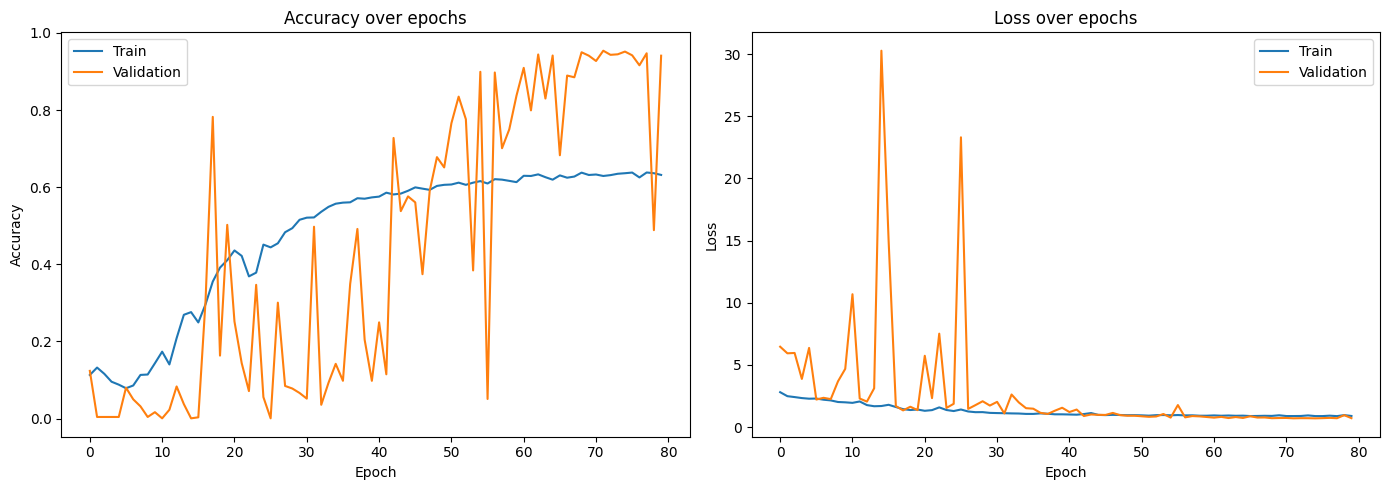

Saved training_history.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig("/content/training_history.png")
plt.show()
print("Saved training_history.png")

In [28]:
best_model = keras.models.load_model(CHECKPOINT_PATH)

test_loss, test_acc = best_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc*100:.2f}%")

y_pred_probs = best_model.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Test loss: 0.7112
Test accuracy: 95.64%

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.82      1.00      0.90         9
           2       0.97      0.94      0.96        36
           3       0.96      0.99      0.98       111
           4       1.00      0.97      0.98       213
           5       0.99      0.99      0.99       278
           6       0.98      0.98      0.98       256
           7       0.88      0.91      0.89       160
           8       0.76      0.71      0.74       122
           9       0.88      0.93      0.90       163
          10       1.00      0.97      0.98       252
          11       0.99      0.99      0.99       268
          12       0.99      0.99      0.99       222
          13       0.99      0.98      0.99       113
          14       0.94      0.86      0.90        36
          15       0.69      1.00      0.82         9
          16     

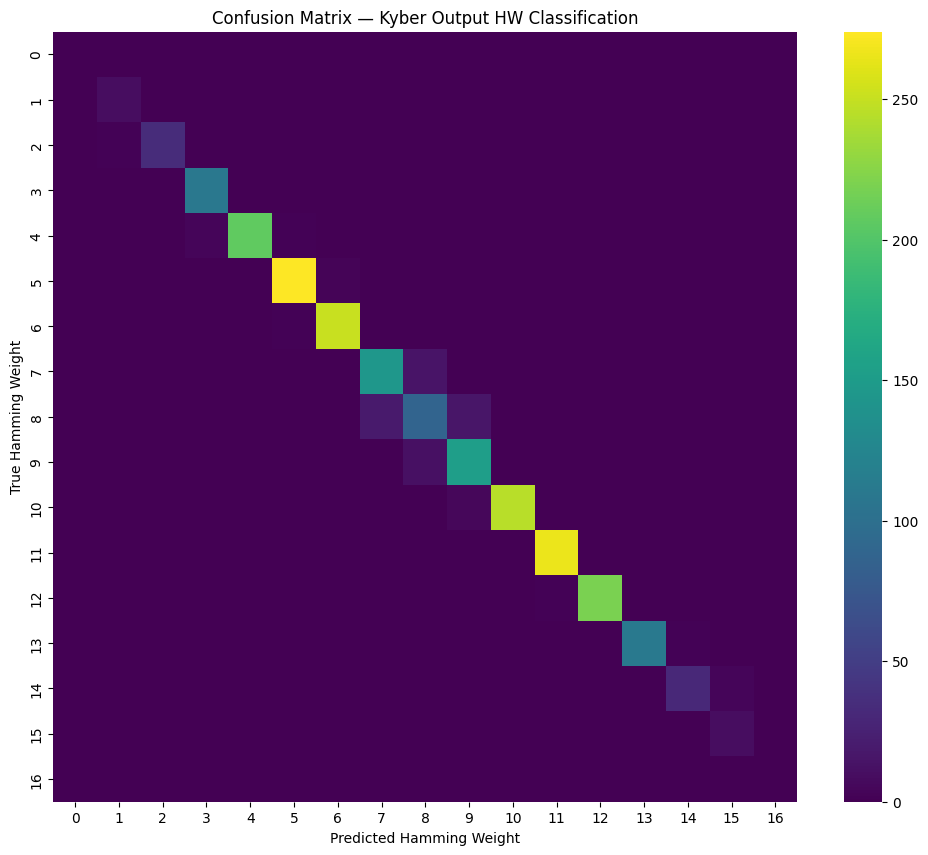

Saved confusion_matrix.png


In [29]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='viridis',
            xticklabels=list(range(NUM_CLASSES)), yticklabels=list(range(NUM_CLASSES)))
plt.xlabel("Predicted Hamming Weight")
plt.ylabel("True Hamming Weight")
plt.title("Confusion Matrix — Kyber Output HW Classification")
plt.savefig("/content/confusion_matrix.png")
plt.show()
print("Saved confusion_matrix.png")

In [30]:
sample_indices = np.random.choice(len(X_test_cnn), size=10, replace=False)

print(f"{'Actual HW':<10}{'Predicted HW':<14}{'Confidence':<12}{'Correct?'}")
for idx in sample_indices:
    probs = y_pred_probs[idx]
    pred = np.argmax(probs)
    conf = probs[pred] * 100
    actual = int(y_test[idx])
    correct = "YES" if pred == actual else "no"
    print(f"{actual:<10}{pred:<14}{conf:<12.1f}{correct}")

Actual HW Predicted HW  Confidence  Correct?
13        13            50.1        YES
6         6             58.4        YES
11        11            51.8        YES
5         5             62.0        YES
14        14            45.1        YES
6         6             59.4        YES
9         9             51.2        YES
9         9             54.0        YES
9         9             54.0        YES
9         9             51.7        YES


In [31]:
FINAL_MODEL_PATH = "/content/kyber_cnn_model.keras"
best_model.save(FINAL_MODEL_PATH)

# Also copy to Drive if mounted
drive_export_dir = "/content/drive/MyDrive/kyber_cnn_export"
if os.path.exists("/content/drive"):
    os.makedirs(drive_export_dir, exist_ok=True)
    shutil.copy(FINAL_MODEL_PATH, os.path.join(drive_export_dir, "kyber_cnn_model.keras"))
    print("Copied to Drive:", drive_export_dir)

assert os.path.exists(FINAL_MODEL_PATH), "Model file was not created!"
print(f"Saved: {FINAL_MODEL_PATH}")
print(f"Size: {os.path.getsize(FINAL_MODEL_PATH) / 1e6:.2f} MB")

Copied to Drive: /content/drive/MyDrive/kyber_cnn_export
Saved: /content/kyber_cnn_model.keras
Size: 1.64 MB


In [32]:
with open("/content/preprocessing_config.json", "w") as f:
    json.dump(preprocessing_config, f, indent=2)

print("Saved preprocessing_config.json:")
print(json.dumps(preprocessing_config, indent=2))
print("\nNo scaler.pkl is needed — normalization is per-trace (mean/std computed on the")
print("incoming trace itself), so there is no fitted object to persist. VS Code must apply")
print("the SAME function: normalize -> downsample by factor", preprocessing_config["downsample_factor"])

Saved preprocessing_config.json:
{
  "normalization": "per_trace_zscore",
  "downsample_method": "average_pooling",
  "downsample_factor": 10,
  "original_length": 50000,
  "processed_length": 5000
}

No scaler.pkl is needed — normalization is per-trace (mean/std computed on the
incoming trace itself), so there is no fitted object to persist. VS Code must apply
the SAME function: normalize -> downsample by factor 10


In [33]:
label_mapping = {str(i): i for i in range(NUM_CLASSES)}
with open("/content/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=2)

print("Saved label_mapping.json:")
print(json.dumps(label_mapping, indent=2))

Saved label_mapping.json:
{
  "0": 0,
  "1": 1,
  "2": 2,
  "3": 3,
  "4": 4,
  "5": 5,
  "6": 6,
  "7": 7,
  "8": 8,
  "9": 9,
  "10": 10,
  "11": 11,
  "12": 12,
  "13": 13,
  "14": 14,
  "15": 15,
  "16": 16
}


In [34]:
model_metadata = {
    "model_name": "kyber_cnn_model",
    "num_classes": NUM_CLASSES,
    "input_shape": list(X_train_cnn.shape[1:]),
    "sequence_length": int(X_train_cnn.shape[1]),
    "num_training_samples": int(X_train.shape[0]),
    "num_validation_samples": int(X_val.shape[0]),
    "num_test_samples": int(X_test.shape[0]),
    "random_seed": RANDOM_SEED,
    "preprocessing_method": preprocessing_config,
    "epochs_run": len(history.history['loss']),
    "best_validation_accuracy": float(max(history.history['val_accuracy'])),
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss),
    "tensorflow_version": tf.__version__
}

with open("/content/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print(json.dumps(model_metadata, indent=2))

{
  "model_name": "kyber_cnn_model",
  "num_classes": 17,
  "input_shape": [
    5000,
    1
  ],
  "sequence_length": 5000,
  "num_training_samples": 10500,
  "num_validation_samples": 2250,
  "num_test_samples": 2250,
  "random_seed": 42,
  "preprocessing_method": {
    "normalization": "per_trace_zscore",
    "downsample_method": "average_pooling",
    "downsample_factor": 10,
    "original_length": 50000,
    "processed_length": 5000
  },
  "epochs_run": 80,
  "best_validation_accuracy": 0.9537777900695801,
  "test_accuracy": 0.9564444422721863,
  "test_loss": 0.7111589908599854,
  "tensorflow_version": "2.20.0"
}


In [35]:
reloaded_model = keras.models.load_model("/content/kyber_cnn_model.keras")

with open("/content/preprocessing_config.json") as f:
    reloaded_config = json.load(f)

# Take an UNSEEN test sample (not used in training)
test_idx = 0
raw_trace = traces[X_test.shape[0] * 0:][0:1]  # placeholder guard, replaced below
# Correct approach: pull directly from the held-out X_test set (already preprocessed) to avoid
# re-deriving indices; this simulates "a new trace arrives already in the same raw format"
sample_raw = X_test[test_idx][np.newaxis, ...]      # already normalized+downsampled, shape (1, 5000)
sample_input = sample_raw[..., np.newaxis]          # shape (1, 5000, 1)

pred_probs = reloaded_model.predict(sample_input, verbose=0)[0]
pred_class = int(np.argmax(pred_probs))
confidence = float(pred_probs[pred_class] * 100)
actual_class = int(y_test[test_idx])

print(f"Actual HW: {actual_class}")
print(f"Predicted HW: {pred_class}")
print(f"Confidence: {confidence:.1f}%")
print("\nReload + inference successful — model works independently of the training session.")

Actual HW: 5
Predicted HW: 5
Confidence: 65.8%

Reload + inference successful — model works independently of the training session.


In [36]:
EXPORT_DIR = "/content/kyber_cnn_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

files_to_export = [
    "kyber_cnn_model.keras",
    "preprocessing_config.json",
    "label_mapping.json",
    "model_metadata.json",
    "training_history.png",
    "confusion_matrix.png",
]

for fname in files_to_export:
    src = os.path.join("/content", fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(EXPORT_DIR, fname))
    else:
        print(f"WARNING: {fname} not found, skipping.")

print("Export folder contents:")
print(os.listdir(EXPORT_DIR))

Export folder contents:
['kyber_cnn_model.keras', 'preprocessing_config.json', 'confusion_matrix.png', 'label_mapping.json', 'training_history.png', 'model_metadata.json']


In [37]:
shutil.make_archive("/content/kyber_cnn_model_package", 'zip', EXPORT_DIR)
shutil.copy("/content/kyber_cnn_model_package.zip", "/content/drive/MyDrive/kyber_cnn_model_package.zip")

from google.colab import files
files.download("/content/kyber_cnn_model_package.zip")
print("Done.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.
